# Import all requirements

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Dataset

In [2]:
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 60)

CSV = "logistics_predictive_maintenanceV2.csv"
data = pd.read_csv(CSV)
print("shape:", data.shape)

shape: (250000, 50)


In [3]:
data.sample(5)

,Vehicle_ID,Make_and_Model,Vehicle_Type,Year_of_Manufacture,Route_Info,Weather_Conditions,Road_Conditions,Communication_Interface,Telematics_Gateway,Edge_Device_Class,Usage_Hours,Load_Capacity,Actual_Load,Engine_Temperature,Tire_Pressure,Fuel_Consumption,Battery_Status,Vibration_Levels,Oil_Quality,Failure_History,Anomalies_Detected,Diagnostic_Trouble_Code_Count,CAN_Message_Rate_Hz,Sensor_Packet_Loss_Rate,Maintenance_Cost,Historical_Maintenance_Cost,Downtime_Maintenance,Impact_on_Efficiency,Days_Since_Last_Maintenance,Last_Maintenance_Date,Maintenance_Type,Brake_Condition,Maintenance_Severity,Maintenance_Severity_ID,Maintenance_Required,PCR,UIR,TPI,MBF,ADS,OHI,CMES,UER,Predictive_Score,Pre_Event_Record,Data_Split,FL_Client_ID,Partition_Type,Local_Epochs_Per_Round,Communication_Rounds
145464,145465,Isuzu NPR,Medium Truck,2012,Highway Freight,Hot,Moderate,CAN/LIN,OBD_Gateway,Automotive_ECU,19215.8994,10000,5873.0990,83.5135,32.7885,7.8614,85.9673,1.4988,80.0850,0,0,0,43.3772,0.0142,479.8104,479.8104,0.1869,0.1649,102,2024-09-21,Oil Check,Good,Normal,0,0,0.5873,0.6863,2.5470,479.8104,0.0,2.2706,1.4836,39.9656,0.2211,1,Train,3,Non-IID Dirichlet alpha=0.5,2,200
79538,79539,MAN TGX,Medium Truck,2015,Urban Delivery,Cold,Moderate,OBD-II/CAN,Edge_Telematics_Box,ARM_Cortex_A72,14624.5253,25000,18696.6549,92.8071,35.6694,7.4593,87.9944,0.9183,85.0262,0,0,0,31.9940,0.0073,403.6100,403.6100,0.2796,0.1364,112,2024-09-11,Oil Check,Fair,Normal,0,0,0.7479,0.6648,2.6019,403.6100,0.0,1.7040,1.2973,36.1447,0.2241,1,Train,3,Non-IID Dirichlet alpha=0.5,2,200
156034,156035,Chevy Silverado,Heavy Truck,2017,Urban Delivery,Clear,Rough,OBD-II/CAN,OBD_Gateway,NVIDIA_Jetson_Nano,11446.6763,2500,2592.0032,117.3208,25.9615,17.1385,52.5435,6.0080,60.5979,1,2,6,74.6354,0.0469,3815.5526,3815.5526,12.0358,0.3704,713,2023-01-19,Electrical Repair,Poor,Major Maintenance,2,1,1.0368,0.6359,4.5190,4769.4407,3.7,2.1395,18.3836,2.9992,0.6045,1,Train,4,Non-IID Dirichlet alpha=0.5,2,200
170769,170770,Mercedes Actros,Heavy Truck,2015,Intercity Logistics,Clear,Smooth,CAN-FD/Telematics,Embedded_TCU,Automotive_ECU,14143.3427,25000,10420.5104,94.3737,32.1998,8.2845,85.5166,0.2413,84.1028,0,0,0,24.0033,0.0074,266.5147,266.5147,0.8212,0.1542,117,2024-09-06,Routine Inspection,Good,Normal,0,0,0.4168,0.6429,2.9309,266.5147,0.0,1.5974,2.0989,52.8694,0.2369,1,Train,1,Non-IID Dirichlet alpha=0.5,2,200
30394,30395,Mercedes Actros,Medium Truck,2015,Highway Freight,Humid,Mountainous,OBD-II/CAN,Edge_Telematics_Box,Automotive_ECU,15582.1719,5000,3723.4327,94.2715,33.0119,7.3964,88.2895,1.4920,81.6387,0,0,1,27.5831,0.0037,439.9402,439.9402,0.6766,0.1916,82,2024-10-11,Tire Rotation,Good,Normal,0,0,0.7447,0.7083,2.8557,439.9402,0.2,1.8910,2.0937,35.3385,0.2590,1,Train,1,Non-IID Dirichlet alpha=0.5,2,200


# Understand the Data

In [4]:
data.shape

(250000, 50)

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 50 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Vehicle_ID                     250000 non-null  int64  
 1   Make_and_Model                 250000 non-null  str    
 2   Vehicle_Type                   250000 non-null  str    
 3   Year_of_Manufacture            250000 non-null  int64  
 4   Route_Info                     250000 non-null  str    
 5   Weather_Conditions             250000 non-null  str    
 6   Road_Conditions                250000 non-null  str    
 7   Communication_Interface        250000 non-null  str    
 8   Telematics_Gateway             250000 non-null  str    
 9   Edge_Device_Class              250000 non-null  str    
 10  Usage_Hours                    250000 non-null  float64
 11  Load_Capacity                  250000 non-null  int64  
 12  Actual_Load                    250000 non

Fix Date data-type

In [6]:
data['Last_Maintenance_Date'] = pd.to_datetime(data['Last_Maintenance_Date'])

In [7]:
data.isnull().sum()

Vehicle_ID                       0
Make_and_Model                   0
Vehicle_Type                     0
Year_of_Manufacture              0
Route_Info                       0
Weather_Conditions               0
Road_Conditions                  0
Communication_Interface          0
Telematics_Gateway               0
Edge_Device_Class                0
Usage_Hours                      0
Load_Capacity                    0
Actual_Load                      0
Engine_Temperature               0
Tire_Pressure                    0
Fuel_Consumption                 0
Battery_Status                   0
Vibration_Levels                 0
Oil_Quality                      0
Failure_History                  0
Anomalies_Detected               0
Diagnostic_Trouble_Code_Count    0
CAN_Message_Rate_Hz              0
Sensor_Packet_Loss_Rate          0
Maintenance_Cost                 0
Historical_Maintenance_Cost      0
Downtime_Maintenance             0
Impact_on_Efficiency             0
Days_Since_Last_Main

In [8]:
data.duplicated().sum()

np.int64(0)

# Categorize the columns

### Removing unwanted columns

In [9]:
data[['Maintenance_Required', 'Load_Capacity', 'Actual_Load', 'PCR']].corr()

,Maintenance_Required,Load_Capacity,Actual_Load,PCR
Maintenance_Required,1.000000,0.000088,0.222758,0.668414
Load_Capacity,0.000088,1.000000,0.911354,0.001868
Actual_Load,0.222758,0.911354,1.000000,0.334937
PCR,0.668414,0.001868,0.334937,1.000000


No of unique values in 'Pre_Event_Record' Column:  1


,Maintenance_Required,Predictive_Score,Maintenance_Severity_ID
Maintenance_Required,1.000000,0.864786,0.921132
Predictive_Score,0.864786,1.000000,0.963906
Maintenance_Severity_ID,0.921132,0.963906,1.000000


<Axes: xlabel='Predictive_Score', ylabel='Count'>

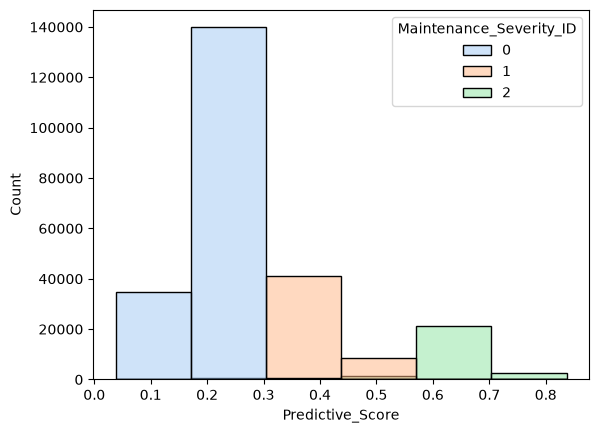

In [10]:
print("No of unique values in 'Pre_Event_Record' Column: ", data['Pre_Event_Record'].nunique())
display(data[['Maintenance_Required','Predictive_Score', 'Maintenance_Severity_ID']].corr())

sns.histplot( x = data['Predictive_Score'], hue=data['Maintenance_Severity_ID'], bins=6, palette="pastel")

In [11]:
# Feature used to extract new featues > No need
OPTIMISED = ['Load_Capacity', 'Actual_Load']

#Does not take any part in final prediction 
USELESS = ['Communication_Interface','Telematics_Gateway','Edge_Device_Class', # Useless data about IoT Device
           'Pre_Event_Record', 'Predictive_Score']

# Features for training/ Testing, model training
FL = ['FL_Client_ID', 'Partition_Type', 'Local_Epochs_Per_Round', 'Communication_Rounds']

to_drop =  OPTIMISED + USELESS  + FL # Pre_Event_Record contain one one value
data.drop(to_drop, axis = 1, inplace = True)

### Categorise Features

In [12]:
data.nunique()

Vehicle_ID                       250000
Make_and_Model                        8
Vehicle_Type                          5
Year_of_Manufacture                  15
Route_Info                            5
Weather_Conditions                    6
Road_Conditions                       5
Usage_Hours                      249199
Engine_Temperature               178710
Tire_Pressure                    111961
Fuel_Consumption                  95782
Battery_Status                   188946
Vibration_Levels                  58297
Oil_Quality                      182536
Failure_History                      11
Anomalies_Detected                   14
Diagnostic_Trouble_Code_Count        17
CAN_Message_Rate_Hz              192551
Sensor_Packet_Loss_Rate             988
Maintenance_Cost                 241458
Historical_Maintenance_Cost      241458
Downtime_Maintenance              80100
Impact_on_Efficiency               6949
Days_Since_Last_Maintenance         701
Last_Maintenance_Date               701


In [13]:
IDS = ['Vehicle_ID','Make_and_Model','Vehicle_Type','Year_of_Manufacture','Route_Info']

# Impactfull features
FEATURES = ['Weather_Conditions','Road_Conditions','Usage_Hours',
            'Engine_Temperature','Tire_Pressure','Fuel_Consumption','Battery_Status','Vibration_Levels','Oil_Quality',
            'Brake_Condition', ]

PAST = ['Failure_History', 'Maintenance_Cost', 'Historical_Maintenance_Cost', 'Downtime_Maintenance',
        'Impact_on_Efficiency', 'Days_Since_Last_Maintenance', 'Last_Maintenance_Date', 'Maintenance_Type']

UNKNOWN = ['Anomalies_Detected', 'Diagnostic_Trouble_Code_Count', 'CAN_Message_Rate_Hz', 'Sensor_Packet_Loss_Rate', ]

# Extracted Features
E_FEATURE = ['PCR','UIR','TPI','MBF','ADS','OHI','CMES','UER']                          # Valid : PCR

# Predefined train-test-split column
TRAIN_TEST_SPLIT= ['Data_Split']
# Outputs
LABELS = ['Maintenance_Required', 'Maintenance_Severity', 'Maintenance_Severity_ID']

In [14]:
CAT = ['Make_and_Model', 'Vehicle_Type', 'Year_of_Manufacture', 'Route_Info',              # IDS
       'Weather_Conditions', 'Road_Conditions',                                 
       'Failure_History', 'Anomalies_Detected', 'Diagnostic_Trouble_Code_Count',           # for both CAT/NUM
       'Maintenance_Type',
       'Brake_Condition',]

NUM = ['Usage_Hours', 
       'Engine_Temperature', 'Tire_Pressure', 'Fuel_Consumption', 'Battery_Status', 'Vibration_Levels', 'Oil_Quality',
        'Failure_History','Anomalies_Detected', 'Diagnostic_Trouble_Code_Count',           # for both CAT/NUM
        'CAN_Message_Rate_Hz', 'Sensor_Packet_Loss_Rate', 
        'Maintenance_Cost', 'Historical_Maintenance_Cost', 'Downtime_Maintenance', 'Impact_on_Efficiency', 
        'Days_Since_Last_Maintenance', 'Last_Maintenance_Date','Maintenance_Type']

In [15]:
used = list(set(IDS + FEATURES + PAST + CAT + NUM + LABELS + E_FEATURE + UNKNOWN + TRAIN_TEST_SPLIT))

F = list(data.drop(used, axis = 1).columns)
print("n_features:", len(F))

n_features: 0


In [27]:
TO_USE = list(set(CAT + NUM + E_FEATURE 
                + LABELS 
                + TRAIN_TEST_SPLIT))

F = list(data.drop(TO_USE, axis = 1).columns)
print("n_features:", len(F))
F

n_features: 1


['Vehicle_ID']

In [17]:
len(list(data.columns))

39

In [18]:
len(TO_USE)

38

# Till Wednesday

In [37]:
df = data.drop(['Vehicle_ID', 'Maintenance_Required', 'Maintenance_Severity'], axis = 1)

# Train test split

In [28]:
df = data.drop(['Vehicle_ID', 'Maintenance_Required', 'Maintenance_Severity'], axis = 1)
df['Data_Split'].value_counts()

Data_Split
Train         175000
Test           50000
Validation     25000
Name: count, dtype: int64

In [32]:
train = df[df['Data_Split'] == 'Train']
test = df[df['Data_Split'] == 'Test']
Validation_set = df[df['Data_Split'] == 'Validation']

Validation_set = Validation_set[df.columns]
X_train, y_train = train[df.columns], train['Maintenance_Severity_ID']
X_test, y_test = test[df.columns], test['Maintenance_Severity_ID']

In [36]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape, Validation_set.shape

((175000, 36), (175000,), (50000, 36), (50000,), (25000, 36))

# EDA

## Categorical Column Analysis

## Numerical Column Analysis

### Heatmap

In [ ]:
df.corr(numeric_only= True)

In [ ]:
df.corr(numeric_only= True)

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only= True))

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only= True))

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only= True))

### Histogram

In [ ]:
df.info()

In [ ]:
plt.figure(figsize=(60, 40))

for i in range(0, len(NUM)):
    plt.subplot(7, 4, i+1)
    sns.histplot(data=df, x=NUM[i], hue='Maintenance_Required', bins=30)
    plt.xlabel(NUM[i])
    plt.tight_layout()

In [ ]:
plt.figure(figsize=(20, 5))

for i in range (9,12):
  plt.subplot(1, 3, i-8)
  plt.title("Hue: " + NUM[i])
  sns.countplot(data=df, x='Maintenance_Required', hue = NUM[i],palette="pastel")
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  plt.xlabel('Maintenance_Required')
  plt.tight_layout()

### Boxplot for outlier

In [ ]:
plt.figure(figsize=(15, 10))

for i in range(0, len(NUM)):
    plt.subplot(7, 4, i+1)
    sns.boxplot(x=df[NUM[i]], color='blue')
    plt.xlabel(NUM[i])
    plt.tight_layout()

# ydata-profiling

In [ ]:
from ydata_profiling import ProfileReport


C:\Users\tosha\AppData\Local\Temp\ipykernel_26364\4135506147.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title="Predictive Maintenance Dataset Report"    
)

profile.to_file("maintenance_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 36/36 [00:03<00:00,  9.27it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
ProfileReport

ydata_profiling.profile_report.ProfileReport